In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/digit-recognizer/sample_submission.csv
/kaggle/input/competitions/digit-recognizer/train.csv
/kaggle/input/competitions/digit-recognizer/test.csv


In [31]:
data=pd.read_csv(r'/kaggle/input/competitions/digit-recognizer/train.csv')
data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [32]:
data.shape

(42000, 785)

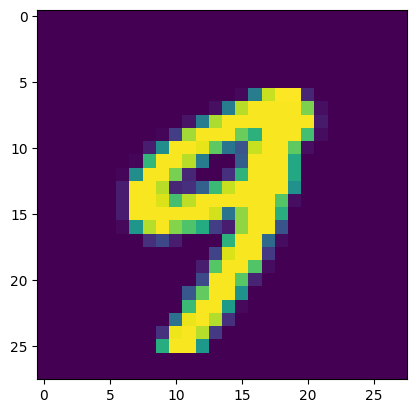

In [34]:
import matplotlib.pyplot as plt

plt.imshow(data.iloc[323,1:].values.reshape(28,28))
plt.show()

In [35]:
X=data.iloc[:,1:]
y=data.iloc[:,0]

In [36]:
from sklearn.model_selection import train_test_split,cross_val_score
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape,X_test.shape

((33600, 784), (8400, 784))

In [37]:
from sklearn.neighbors import KNeighborsClassifier
clf=KNeighborsClassifier()

In [38]:
clf.fit(X_train,y_train)

KNeighborsClassifier()

In [39]:
import time
start=time.time()
y_pred=clf.predict(X_test)
print(time.time()-start)

10.568604946136475


In [40]:
from sklearn.metrics import accuracy_score
score=accuracy_score(y_test,y_pred)
score

0.9648809523809524

In [41]:
from sklearn.preprocessing import StandardScaler

In [42]:
scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)


In [43]:
X_test

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [60]:
from sklearn.decomposition import PCA
pca = PCA(n_components=150)

In [61]:
X_train_new=pca.fit_transform(X_train)
X_test_new=pca.transform(X_test)

In [62]:
X_train_new.shape,X_test_new.shape

((33600, 150), (8400, 150))

In [63]:
clf1=KNeighborsClassifier()

clf1.fit(X_train_new,y_train)
y_pred=clf1.predict(X_test_new)

score=accuracy_score(y_test,y_pred)
score

0.9520238095238095

In [69]:
for i in range(100,784):
    pca = PCA(n_components=i)
    X_train_new=pca.fit_transform(X_train)
    X_test_new=pca.transform(X_test)
    clf1=KNeighborsClassifier()

    clf1.fit(X_train_new,y_train)
    y_pred=clf1.predict(X_test_new)

    score=accuracy_score(y_test,y_pred)
    print(score,":",i)
    
    

In [66]:
pca=PCA(n_components=2)
X_train_new=pca.fit_transform(X_train)
X_test_new=pca.transform(X_test)

In [70]:
import plotly.express as px
y_train_new = y_train.astype(str)
fig = px.scatter(x=X_train_new[:,0],
                 y=X_train_new[:,1],
                 color=y_train_new,
                 color_discrete_sequence=px.colors.qualitative.G10
                )
fig.show()

In [71]:
pca.explained_variance_

array([40.67111198, 29.17023401])

In [72]:
pca.components_

array([[ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [-0., -0., -0., ..., -0., -0., -0.]])

In [75]:
pca.explained_variance_ratio_*100

array([5.78519225, 4.14926968])

In [77]:
pca = PCA()
X_train_new=pca.fit_transform(X_train)
X_test_new=pca.transform(X_test)

In [79]:
np.cumsum(pca.explained_variance_ratio_*100)

array([  5.78519225,   9.93446193,  13.73870094,  16.70496371,
        19.2865254 ,  21.54150558,  23.5145736 ,  25.28985357,
        26.85850424,  28.29456752,  29.66482235,  30.89207736,
        32.03898935,  33.16201674,  34.22054559,  35.24047664,
        36.1981528 ,  37.14086161,  38.05335104,  38.94352123,
        39.78346173,  40.60352492,  41.38882815,  42.14556786,
        42.88282888,  43.58471353,  44.28263326,  44.95373775,
        45.59358278,  46.22392007,  46.83927092,  47.44165957,
        48.02533355,  48.6038813 ,  49.17621445,  49.72261423,
        50.2658216 ,  50.79399435,  51.30737609,  51.80139157,
        52.28906267,  52.77104144,  53.23924587,  53.69858836,
        54.15624919,  54.60546821,  55.05015043,  55.49169118,
        55.92680312,  56.35883605,  56.78064492,  57.19888804,
        57.60688239,  58.00888731,  58.40722316,  58.80182197,
        59.18869358,  59.57188877,  59.94844139,  60.32263485,
        60.68748701,  61.04828955,  61.402176  ,  61.75

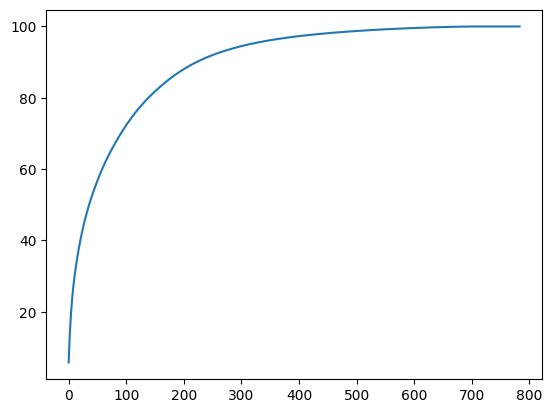

In [82]:
plt.plot(np.cumsum(pca.explained_variance_ratio_*100))
plt.show()